## Methodology

### Training and Iterate Collection

A ResNet Model is trained on 15,000 CIFAR-10 samples using SGD ($\eta=0.1$, $\mu=0.9$, weight decay $10^{-4}$, batch size 128, 16 epochs). After every mini-batch update the full parameter vector is stored in float32, yielding $T \approx 1{,}888$ iterates.

### Windowed PCA

To track how the local dimensionality of the trajectory evolves during training, PCA is applied in a sliding window of width 150 iterates (stride 50) over the full iterate sequence. For each window the explained variance ratio of the first principal component (PC1) is recorded as a function of training time. A decreasing PC1 share over time would indicate that the trajectory becomes less directional and more diffuse in later training phases.

### Ornstein–Uhlenbeck Process as Stochastic Model

The SGD trajectory is modelled as a discrete Ornstein–Uhlenbeck (OU) process in the full parameter space:

$$X_t = X_{t-1} + \mu\,(\theta^* - X_{t-1})\,\Delta t + \sigma\,\varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, I)$$

where $\theta^* = \theta_T$ is the final SGD iterate (the attractor), $\mu$ is the mean-reversion (restoring) strength, and $\sigma$ is the per-dimension diffusion strength calibrated from the empirical step-size distribution of the SGD trajectory: $\hat{\sigma}_d = \mathrm{std}_t(\theta_{t,d} - \theta_{t-1,d})$. The process starts at $\theta_0$ and runs for $T$ steps, matching the SGD trajectory in length, start, end point, and noise magnitude. The free parameter $\mu$ controls the balance between directed drift towards $\theta^*$ and isotropic diffusion.

### Calibration via PCA Spectrum Matching

OU trajectories are simulated for a grid of restoring strengths $\mu \in \{0, 10^{-4}, \ldots, 1.5 \times 10^{-3}\}$. For each $\mu$, PCA is applied to the full simulated trajectory and the top-10 normalised eigenvalue shares are extracted. The best-fitting $\mu$ is selected by minimising the Wasserstein distance between the OU eigenvalue spectrum and the SGD eigenvalue spectrum, with sum-of-squared differences as a secondary criterion. The result ($\mu^* = 5 \times 10^{-4}$) identifies the restoring strength at which the OU process reproduces the spectral shape of the SGD trajectory most faithfully, providing a quantitative characterisation of the effective drift-to-noise ratio of SGD in this setting.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import wasserstein_distance

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else
                       "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

TRAIN_SIZE   = 15_000
TEST_SIZE    = 5_000
BATCH_SIZE   = 128
EPOCHS       = 16
LR           = 0.1
MOMENTUM     = 0.9
WEIGHT_DECAY = 1e-4

WINDOW_SIZE  = 150
WINDOW_STEP  = 50
N_PCA_COMPS  = 10

print(f"EPOCHS={EPOCHS}, LR={LR}, BATCH={BATCH_SIZE}, TRAIN={TRAIN_SIZE}, TEST={TEST_SIZE}")

Device: mps
EPOCHS=16, LR=0.1, BATCH=128, TRAIN=15000, TEST=5000


In [4]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

full_train = torchvision.datasets.CIFAR10(root='./data', train=True,
                                           download=True, transform=transform_train)
full_test  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform_test)

train_subset = torch.utils.data.Subset(full_train, range(TRAIN_SIZE))
test_subset  = torch.utils.data.Subset(full_test,  range(TEST_SIZE))

train_loader = torch.utils.data.DataLoader(train_subset, batch_size=BATCH_SIZE,
                                            shuffle=True,  num_workers=0)
test_loader  = torch.utils.data.DataLoader(test_subset,  batch_size=BATCH_SIZE,
                                            shuffle=False, num_workers=0)

print(f"Train-Batches: {len(train_loader)}, Test-Batches: {len(test_loader)}")

Files already downloaded and verified
Files already downloaded and verified
Train-Batches: 118, Test-Batches: 40


In [ ]:
class BasicBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)


class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super().__init__()
        self.in_ch   = 16
        self.conv1   = nn.Conv2d(3, 16, 3, stride=1, padding=1, bias=False)
        self.bn1     = nn.BatchNorm2d(16)
        self.relu    = nn.ReLU(inplace=True)
        self.layer1  = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2  = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3  = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc      = nn.Linear(64, num_classes)

    def _make_layer(self, block, out_ch, num_blocks, stride):
        layers = [block(self.in_ch, out_ch, stride)]
        self.in_ch = out_ch
        for _ in range(1, num_blocks):
            layers.append(block(out_ch, out_ch, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


def resnet20(): return ResNet(BasicBlock, [1, 1, 1])

def count_params(model):
    return sum(p.numel() for p in model.parameters())

print(f"ResNet-20: {count_params(resnet8()):,} Parameter")

In [ ]:
torch.manual_seed(SEED)
np.random.seed(SEED)

print("=" * 55)
print("Training ResNet-20")
print("=" * 55)

model8    = resnet20().to(DEVICE)
opt8      = optim.SGD(model8.parameters(), lr=LR,
                      momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()

iterates8   = []
train_accs8 = []
test_accs8  = []
losses8     = []
step = 0

for epoch in range(EPOCHS):
    model8.train()
    epoch_loss, correct, total = 0.0, 0, 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        opt8.zero_grad()
        outputs = model8(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        opt8.step()

        epoch_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total   += targets.size(0)
        iterates8.append(np.concatenate([p.detach().cpu().numpy().ravel()
                                          for p in model8.parameters()]))
        step += 1

    train_acc = 100. * correct / total
    avg_loss  = epoch_loss / len(train_loader)
    losses8.append(avg_loss)
    train_accs8.append(train_acc)

    model8.eval()
    correct_t, total_t = 0, 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            _, predicted = model8(inputs).max(1)
            correct_t += predicted.eq(targets).sum().item()
            total_t   += targets.size(0)
    test_acc = 100. * correct_t / total_t
    test_accs8.append(test_acc)

    print(f"  Epoch {epoch+1:02d}/{EPOCHS}  loss={avg_loss:.4f}  "
          f"train={train_acc:.1f}%  test={test_acc:.1f}%")

iterates8 = np.array(iterates8)
print(f"\nSnapshots: {len(iterates8)},  Param-Dim: {iterates8.shape[1]:,}")

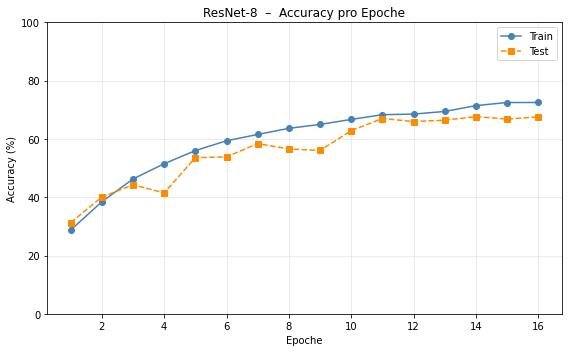

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
epochs_x = range(1, EPOCHS + 1)
ax.plot(epochs_x, train_accs8, marker='o', color='steelblue', label='Train')
ax.plot(epochs_x, test_accs8,  marker='s', color='darkorange',
        linestyle='--', label='Test')
ax.set_title("ResNet-8  –  Accuracy pro Epoche")
ax.set_xlabel("Epoche")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

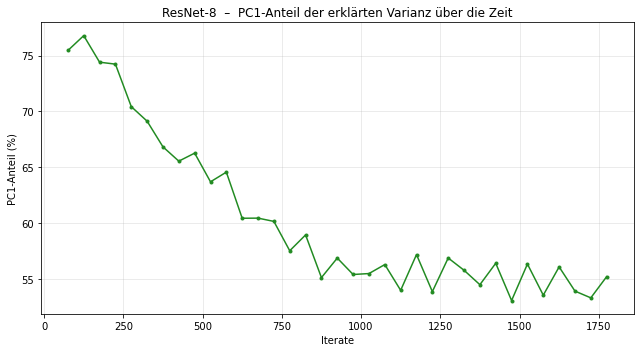

PC1-Anteil:  Start=75.5%   Ende=55.2%


In [8]:
n8      = len(iterates8)
starts8 = list(range(0, n8 - WINDOW_SIZE + 1, WINDOW_STEP))

centers8     = []
pc1_pct_8    = []   # PC1-Anteil in Prozent

for s in starts8:
    window          = iterates8[s:s + WINDOW_SIZE]
    window_centered = window - window.mean(axis=0)
    pca = PCA(n_components=min(N_PCA_COMPS, WINDOW_SIZE - 1))
    pca.fit(window_centered)
    centers8.append(s + WINDOW_SIZE // 2)
    pc1_pct_8.append(pca.explained_variance_ratio_[0] * 100)

centers8  = np.array(centers8)
pc1_pct_8 = np.array(pc1_pct_8)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(centers8, pc1_pct_8, color='forestgreen', marker='o', markersize=3)
ax.set_title("ResNet-8  –  PC1-Anteil der erklärten Varianz über die Zeit")
ax.set_xlabel("Iterate")
ax.set_ylabel("PC1-Anteil (%)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PC1-Anteil:  Start={pc1_pct_8[0]:.1f}%   Ende={pc1_pct_8[-1]:.1f}%")

In [9]:
def simulate_ou(start, end, n_steps, mu, sigma_per_dim, seed=None):
    """
    Simuliert einen Ornstein-Uhlenbeck-Prozess im Parameterraum.
    dX = mu * (end - X) * dt + sigma * dW

    start : Startpunkt (= SGD-Initialisierung)
    end   : Punkt, zu dem die Rückstellkraft hinzieht (= SGD-Endpunkt)
    mu    : Rückstellkraft (Stärke der Anziehung zu `end`)
    sigma_per_dim : Diffusionsstärke pro Dimension (kalibriert auf SGD-Rauschen)
    """
    if seed is not None:
        np.random.seed(seed)

    P = len(start)
    dt = 0.5
    X = np.zeros((n_steps, P))
    X[0] = start

    for t in range(1, n_steps):
        noise = np.random.normal(0.0, sigma_per_dim)
        X[t] = X[t-1] + mu * (end - X[t-1]) * dt + noise

    return X


# ── Kalibrierung der Diffusionsstärke auf SGD-Rauschen ────────────────────────
sgd_steps        = np.diff(iterates8, axis=0)
sigma_per_dim_ou = sgd_steps.std(axis=0)

start_point = iterates8[0]
end_point   = iterates8[-1]
n_steps_ou  = len(iterates8)

print(f"Start-Endpunkt-Distanz: {np.linalg.norm(end_point - start_point):.4f}")
print(f"Ø Diffusionsstärke pro Dim: {sigma_per_dim_ou.mean():.6f}")
print(f"n_steps_ou = {n_steps_ou}")

Start-Endpunkt-Distanz: 31.7422
Ø Diffusionsstärke pro Dim: 0.000519
n_steps_ou = 1888


In [10]:
# ── HIER: mu-Array festlegen ───────────────────────────────────────────────────
mu_array = np.array([0, 0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008, 0.0009, 0.001, 0.00125, 0.0015])

ou_trajectories = {}   # mu -> Trajektorie
pc1_pct_vs_mu   = []   # PC1-Anteil (gesamte Trajektorie-PCA) pro mu

for mu in mu_array:
    traj = simulate_ou(
        start=start_point,
        end=end_point,
        n_steps=n_steps_ou,
        mu=mu,
        sigma_per_dim=sigma_per_dim_ou,
        seed=SEED
    )
    ou_trajectories[mu] = traj

    # PCA auf die GESAMTE Trajektorie (nicht fensterweise)
    traj_centered = traj - traj.mean(axis=0)
    pca_full = PCA(n_components=min(N_PCA_COMPS, n_steps_ou - 1))
    pca_full.fit(traj_centered)
    pc1_pct_vs_mu.append(pca_full.explained_variance_ratio_[0] * 100)

    print(f"mu={mu:<8.4f}  PC1-Anteil (gesamte Traj.) = {pc1_pct_vs_mu[-1]:.2f}%")

pc1_pct_vs_mu = np.array(pc1_pct_vs_mu)

mu=0.0000    PC1-Anteil (gesamte Traj.) = 61.36%
mu=0.0001    PC1-Anteil (gesamte Traj.) = 62.09%
mu=0.0002    PC1-Anteil (gesamte Traj.) = 66.27%
mu=0.0003    PC1-Anteil (gesamte Traj.) = 71.41%
mu=0.0004    PC1-Anteil (gesamte Traj.) = 76.06%
mu=0.0005    PC1-Anteil (gesamte Traj.) = 79.83%
mu=0.0006    PC1-Anteil (gesamte Traj.) = 82.77%
mu=0.0007    PC1-Anteil (gesamte Traj.) = 85.03%
mu=0.0008    PC1-Anteil (gesamte Traj.) = 86.79%
mu=0.0009    PC1-Anteil (gesamte Traj.) = 88.17%
mu=0.0010    PC1-Anteil (gesamte Traj.) = 89.27%
mu=0.0013    PC1-Anteil (gesamte Traj.) = 91.18%
mu=0.0015    PC1-Anteil (gesamte Traj.) = 92.37%


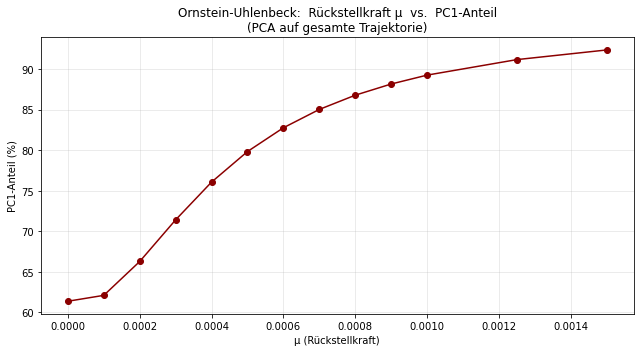

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mu_array, pc1_pct_vs_mu, marker='o', color='darkred')
ax.set_title("Ornstein-Uhlenbeck:  Rückstellkraft μ  vs.  PC1-Anteil\n(PCA auf gesamte Trajektorie)")
ax.set_xlabel("μ (Rückstellkraft)")
ax.set_ylabel("PC1-Anteil (%)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
sgd_traj_centered = iterates8 - iterates8.mean(axis=0)
pca_sgd_full = PCA(n_components=min(N_PCA_COMPS, n_steps_ou - 1))
pca_sgd_full.fit(sgd_traj_centered)

sgd_spectrum_pct = pca_sgd_full.explained_variance_ratio_ * 100

print("SGD-Spektrum (gesamte Trajektorie), Top-10 PCs in %:")
for i, v in enumerate(sgd_spectrum_pct):
    print(f"  PC{i+1}: {v:.2f}%")

SGD-Spektrum (gesamte Trajektorie), Top-10 PCs in %:
  PC1: 79.64%
  PC2: 10.23%
  PC3: 3.15%
  PC4: 1.42%
  PC5: 0.85%
  PC6: 0.61%
  PC7: 0.43%
  PC8: 0.34%
  PC9: 0.29%
  PC10: 0.23%


In [15]:
# ── Eigenwert-Spektren (Top-10, normalisiert) für jedes mu berechnen ──────────
ou_spectra_pct = {}

for mu in mu_array:
    traj = ou_trajectories[mu]
    traj_centered = traj - traj.mean(axis=0)
    pca_full = PCA(n_components=min(N_PCA_COMPS, n_steps_ou - 1))
    pca_full.fit(traj_centered)
    ou_spectra_pct[mu] = pca_full.explained_variance_ratio_ * 100

# ── Distanzen berechnen (Wasserstein + SSD, auf normalisierten Top-10-Anteilen) ─
distances = []
for mu in mu_array:
    a = sgd_spectrum_pct / 100.0          # normiert auf Summe ≈1 (Top10-Anteil)
    b = ou_spectra_pct[mu] / 100.0
    wd  = wasserstein_distance(a, b)
    ssd = np.sum((a - b) ** 2)
    distances.append((mu, wd, ssd))

print(f"{'mu':>10} {'Wasserstein':>14} {'SSD':>14}")
print("-" * 40)
for mu, wd, ssd in distances:
    print(f"{mu:>10.4f} {wd:>14.6f} {ssd:>14.6f}")

# ── Bestes mu finden ────────────────────────────────────────────────────────────
best_wd_idx  = np.argmin([d[1] for d in distances])
best_ssd_idx = np.argmin([d[2] for d in distances])

print(f"\nBestes μ nach Wasserstein-Distanz: μ = {distances[best_wd_idx][0]}")
print(f"Bestes μ nach SSD:                 μ = {distances[best_ssd_idx][0]}")

        mu    Wasserstein            SSD
----------------------------------------
    0.0000       0.033664       0.037876
    0.0001       0.032320       0.034870
    0.0002       0.024590       0.020048
    0.0003       0.015079       0.007563
    0.0004       0.008726       0.001707
    0.0005       0.005045       0.000764
    0.0006       0.007732       0.002379
    0.0007       0.010600       0.005032
    0.0008       0.013426       0.007937
    0.0009       0.015986       0.010737
    0.0010       0.018021       0.013288
    0.0013       0.021576       0.018435
    0.0015       0.023789       0.022088

Bestes μ nach Wasserstein-Distanz: μ = 0.0005
Bestes μ nach SSD:                 μ = 0.0005


In [17]:
# ============================================================
#  Eigenwert-Spektrum: SGD vs. OU-Prozesse
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

LBL, TTL, TCK = 18, 20, 17   # label / title / tick fontsize


def plot_eigenvalue_spectrum(show_title=True):
    fig, ax = plt.subplots(figsize=(11, 6.5), facecolor='white')
    ax.set_facecolor('white')

    pcs = np.arange(1, len(sgd_spectrum_pct) + 1)
    ax.plot(pcs, sgd_spectrum_pct, color='forestgreen', marker='o',
            linewidth=3.0, markersize=8, label='SGD (ResNet-8)', zorder=10)

    colors_ou = plt.cm.coolwarm(np.linspace(0, 1, len(mu_array)))
    for i, mu in enumerate(mu_array):
        ax.plot(pcs, ou_spectra_pct[mu], color=colors_ou[i],
                marker='x', alpha=0.6, linewidth=1.8, label=f'OU μ={mu}')

    # Bestes mu hervorheben
    best_mu = distances[best_wd_idx][0]
    ax.plot(pcs, ou_spectra_pct[best_mu], color='black',
            marker='s', linewidth=2.6, linestyle='--', markersize=7,
            label=f'Best OU μ={best_mu} (W-dist)', zorder=9)

    ax.set_yscale('log')
    ax.set_xlabel("Principal component", fontsize=LBL)
    ax.set_ylabel("Explained variance share (%, log)", fontsize=LBL)
    ax.tick_params(axis='both', labelsize=TCK)

    if show_title:
        ax.set_title("Eigenvalue spectrum (top-10, % explained variance)\n"
                     "SGD vs. OU processes", fontsize=TTL)

    ax.legend(fontsize=TCK - 2, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

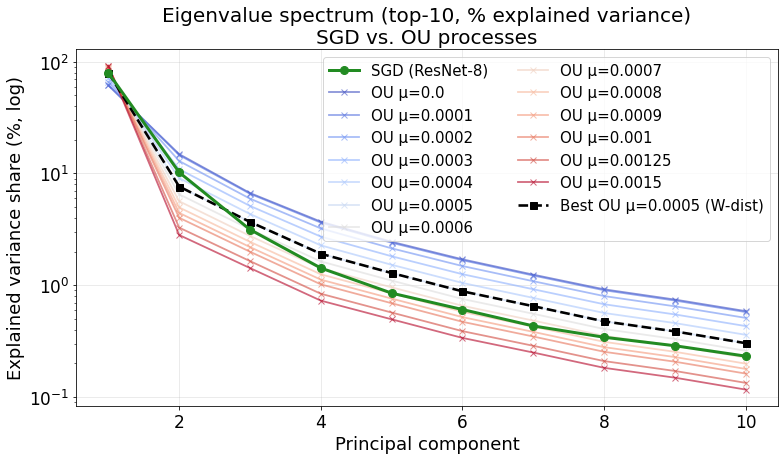

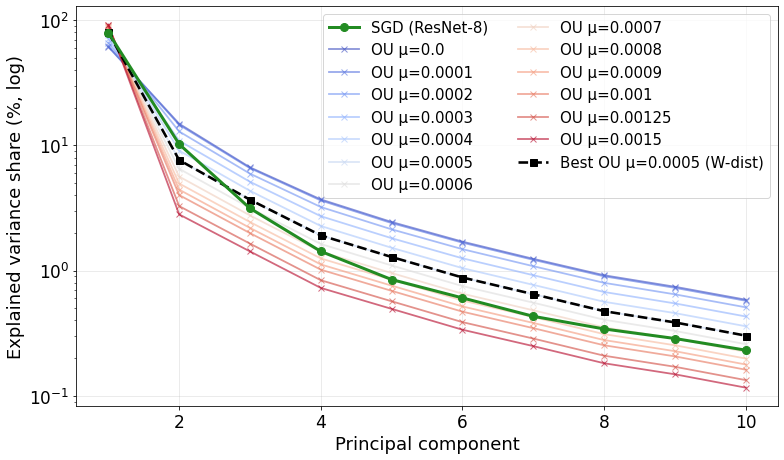


→ The OU spectrum with μ = 0.0005 is closest to the SGD spectrum (measured via Wasserstein distance on the top-10 normalized eigenvalue shares).


In [18]:
plot_eigenvalue_spectrum(show_title=True)
plot_eigenvalue_spectrum(show_title=False)

best_mu = distances[best_wd_idx][0]
print(f"\n→ The OU spectrum with μ = {best_mu} is closest to the SGD spectrum "
      f"(measured via Wasserstein distance on the top-{N_PCA_COMPS} normalized "
      f"eigenvalue shares).")